#  Decision Tree Classification — Demo
### Iris Dataset & Social Network Ads

---

##  Overview

This notebook introduces **Decision Tree Classification** using two classic datasets:

1. **Iris Dataset** — Classify flower species (Setosa, Versicolor, Virginica) using petal/sepal measurements
2. **Social Network Ads** — Predict whether a user will purchase a product based on age and salary

We also explore:
- How to **visualize** a decision tree
- The impact of limiting **tree depth** (`max_depth`)
- Comparing **Gini** vs **Entropy** splitting criteria

---

##  Decision Tree — Quick Recap

A **Decision Tree** builds a model shaped like a tree:
- Starts from a **root node** (best feature to split on)
- Recursively splits data based on feature thresholds
- Stops at **leaf nodes** which hold the final class prediction

**Key Hyperparameters:**

| Parameter | Description | Default |
|-----------|-------------|----------|
| `criterion` | Splitting metric (`gini` or `entropy`) | `gini` |
| `max_depth` | Maximum levels in the tree | `None` (fully grown) |
| `min_samples_split` | Min samples required to split a node | `2` |
| `min_samples_leaf` | Min samples required at a leaf node | `1` |

---
##  Step 1: Import Required Libraries

In [73]:
import pandas as pd                                    # Data manipulation
import numpy as np                                     # Numerical operations
from sklearn.datasets import load_iris                 # Built-in Iris dataset
from sklearn.model_selection import train_test_split   # Train/test splitting
from sklearn.tree import DecisionTreeClassifier        # Decision Tree model
from sklearn.metrics import accuracy_score             # Evaluation metric
from sklearn.tree import plot_tree                     # Tree visualization
import matplotlib.pyplot as plt                        # Plotting
from matplotlib.pylab import rcParams                  # Figure size settings
import warnings 
warnings.filterwarnings('ignore')

---
## Part A: Iris Dataset

### About the Dataset
The **Iris dataset** is one of the most famous datasets in machine learning. It contains **150 samples** of iris flowers from 3 species:
- `0` → Iris Setosa
- `1` → Iris Versicolor
- `2` → Iris Virginica

**4 Features:** sepal length, sepal width, petal length, petal width (all in cm)

> **Why Iris?** It's a clean, well-balanced, multi-class dataset — perfect for demonstrating classifiers.

In [75]:
# Load the built-in Iris dataset from scikit-learn
data = load_iris()

# Extract features (X) and labels (y)
X = data.data    # Shape: (150, 4) — 150 samples, 4 features
y = data.target  # Shape: (150,)  — class labels: 0, 1, 2

### Train / Test Split
We hold out **20%** of data as the test set. `random_state=42` ensures the same split every run (reproducibility).

In [77]:
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train : ', X_train.shape)   # (120, 4)
print('Shape of y_train : ', y_train.shape)   # (120,)
print('Shape of X_test  : ', X_test.shape)    # (30, 4)
print('Shape of y_test  : ', y_test.shape)    # (30,)

Shape of X_train :  (120, 4)
Shape of y_train :  (120,)
Shape of X_test  :  (30, 4)
Shape of y_test  :  (30,)


### Train & Evaluate

> **Note:** By default, `DecisionTreeClassifier()` grows a **fully unconstrained tree** — it keeps splitting until all leaves are pure. This often leads to **overfitting**.

In [79]:
# Train an unconstrained Decision Tree (default: Gini, no max_depth)
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)   # Learn decision rules from training data

# Predict class labels on the test set
y_pred = clf.predict(X_test)
y_pred

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1, 2, 0, 0, 0, 0, 1, 2, 1, 1, 2, 0, 2,
       0, 2, 2, 2, 2, 2, 0, 0])

In [80]:
# Measure accuracy: proportion of correct predictions
print("Accuracy Score For Decision Tree Classifier ::", accuracy_score(y_test, y_pred))

Accuracy Score For Decision Tree Classifier :: 1.0


### Visualize the Decision Tree

`plot_tree()` renders the full tree structure. Each node shows:
- The **splitting condition** (e.g., `petal length <= 2.45`)
- **Gini impurity** of that node
- **Number of samples** reaching that node
- **Class distribution** at that node

> **Tip:** A fully grown tree on a small dataset can be very deep and complex. Use `max_depth` to limit it for better readability.

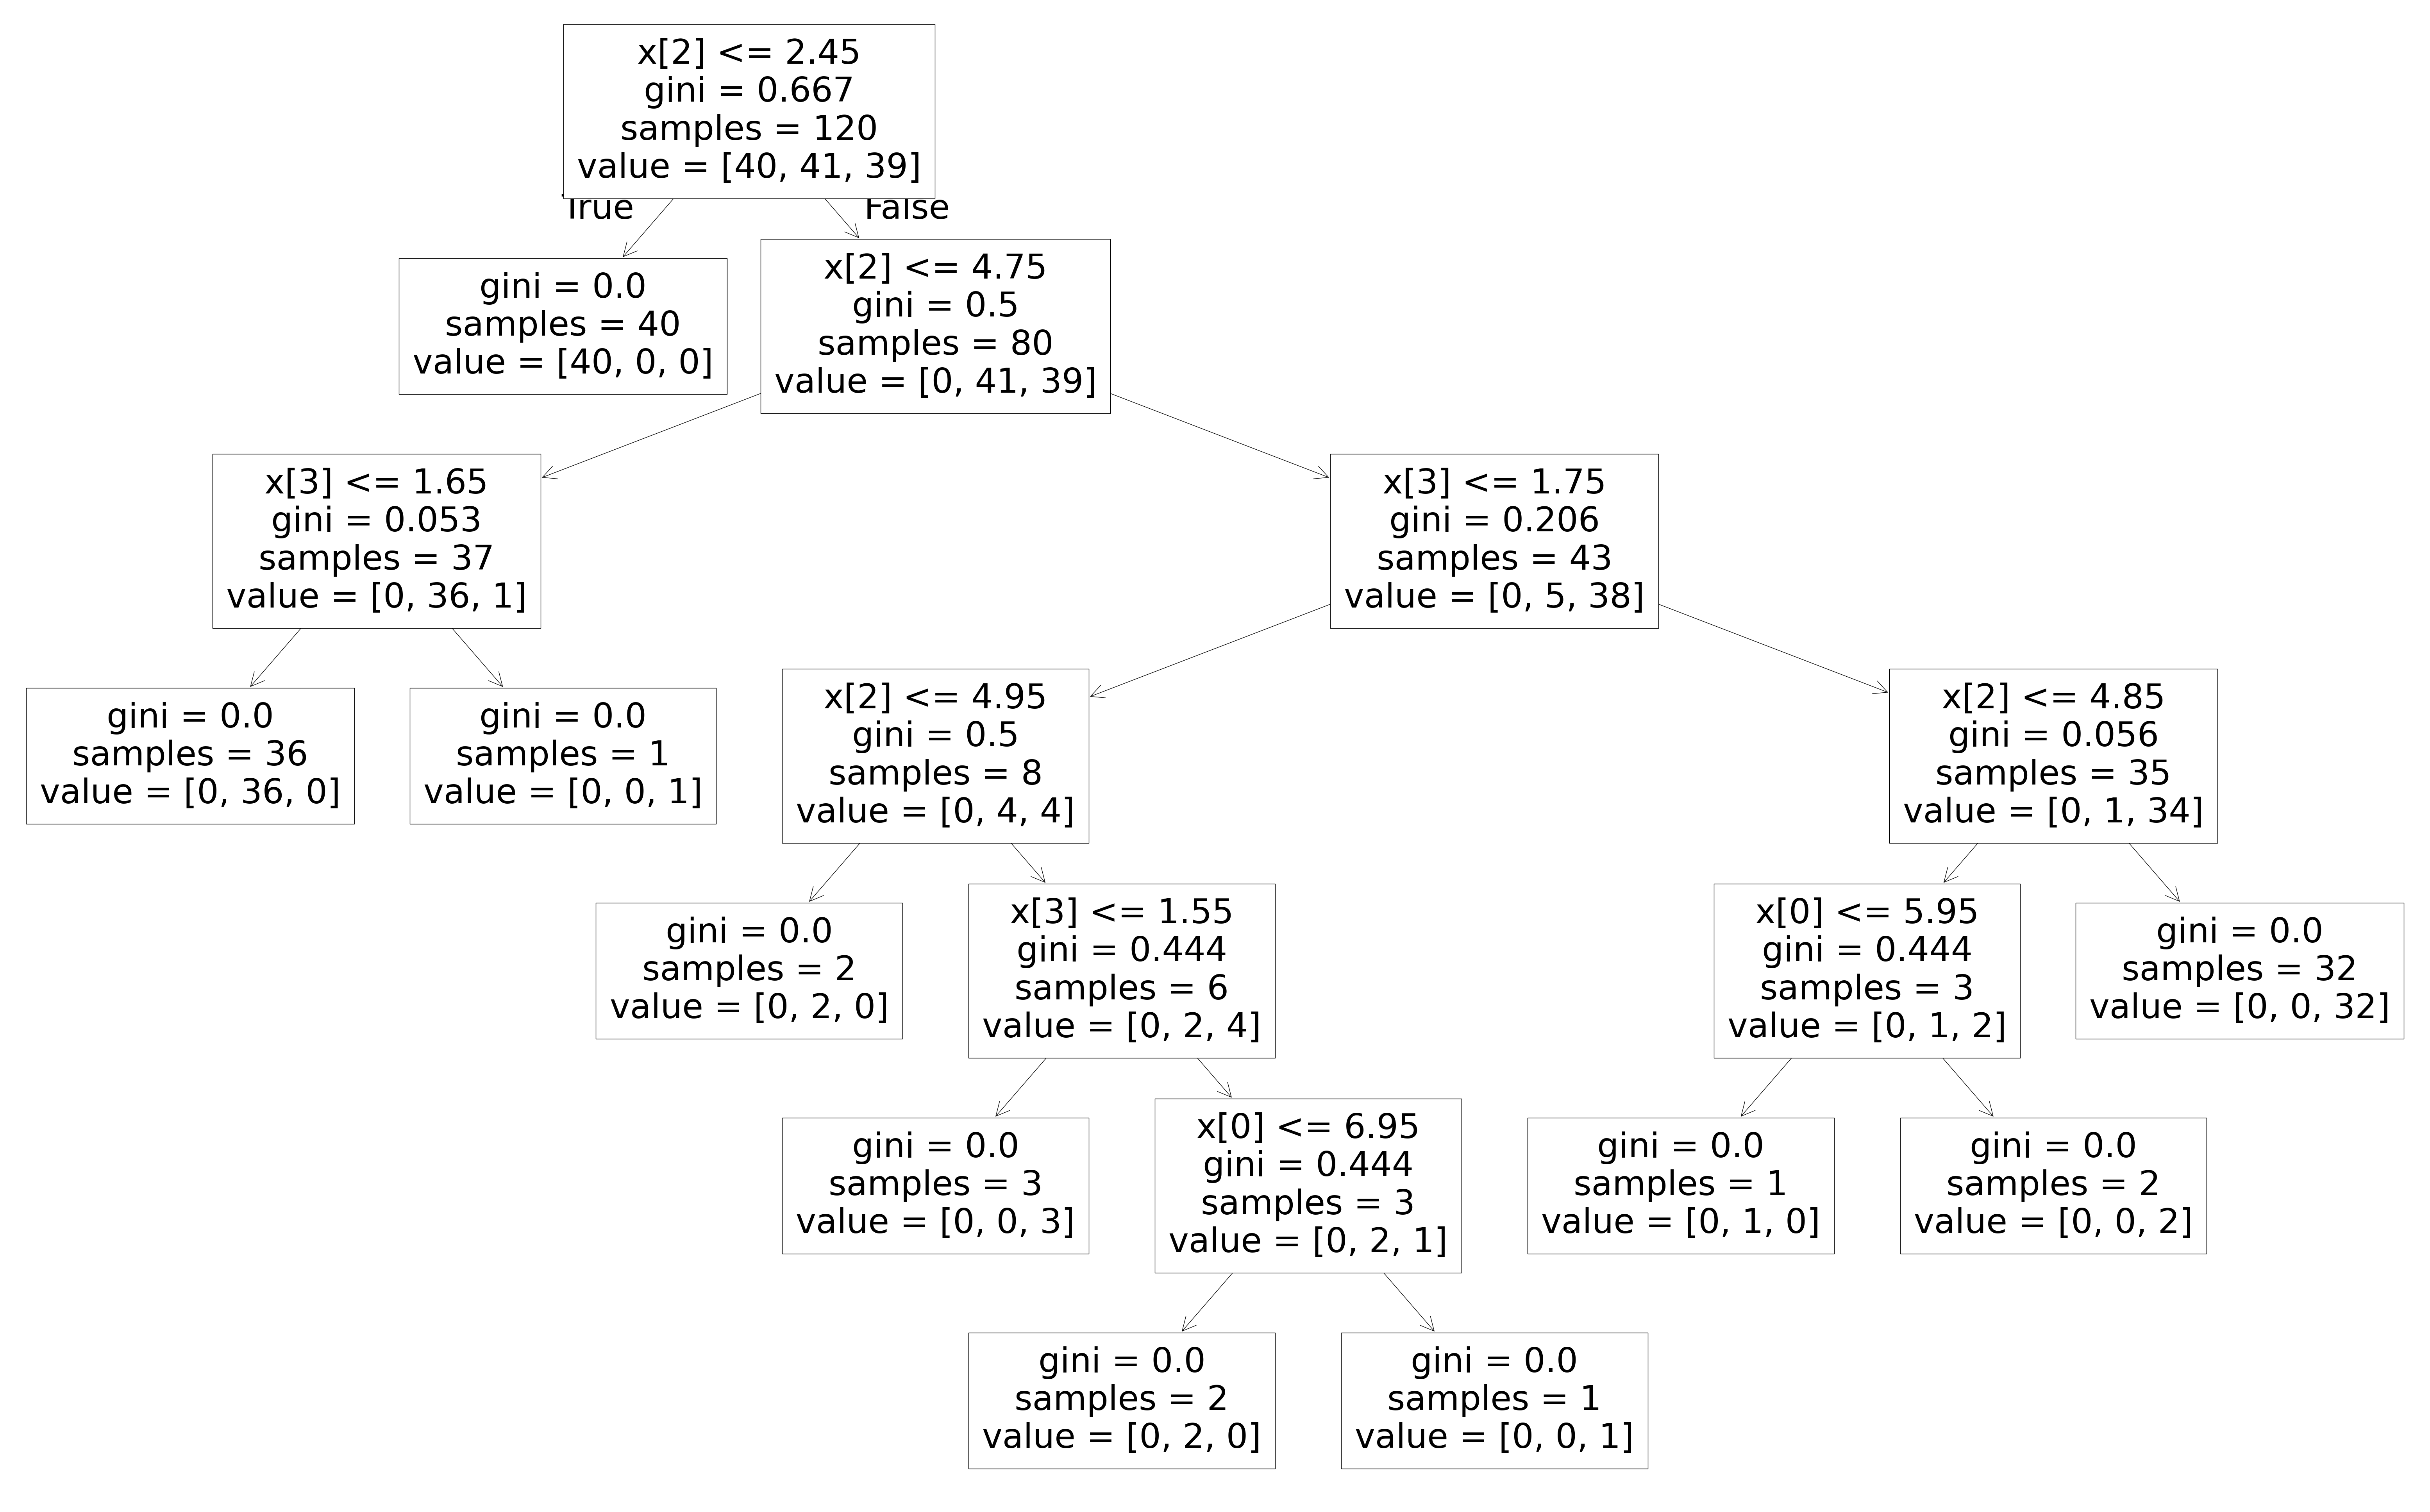

In [82]:
# Set a large figure size to make the tree readable
rcParams['figure.figsize'] = 80, 50

# Plot the full decision tree
plot_tree(clf)
plt.show()

---
## Part B: Social Network Ads Dataset

### About the Dataset
This dataset contains user information from a social network. The goal is to predict whether a user **purchased** a product after seeing an ad.

**Features:**
- `Gender` (encoded: Male=0, Female=1)
- `Age`
- `EstimatedSalary`

**Target:**
- `0` → Did not purchase
- `1` → Purchased

In [84]:
# Load the Social Network Ads dataset
data_1 = pd.read_csv('Social_Network_Ads.csv')

# Encode 'Gender' column: Male → 0, Female → 1
# Decision Trees can handle raw strings, but numeric encoding is best practice
data_1['Gender'] = data_1['Gender'].replace({'Male': 0, 'Female': 1})

data_1.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,0,19,19000,0
1,15810944,0,35,20000,0
2,15668575,1,26,43000,0
3,15603246,1,27,57000,0
4,15804002,0,19,76000,0


### Training with `max_depth=3` (Controlled Tree)

Setting `max_depth=3` limits the tree to **3 levels** of splits. This:
- **Reduces overfitting** by preventing the tree from memorizing noise
- Makes the tree **easier to interpret**
- Trades some training accuracy for better **generalization**

> **Rule of thumb:** Start with small `max_depth` (2–5) and increase only if underfitting.

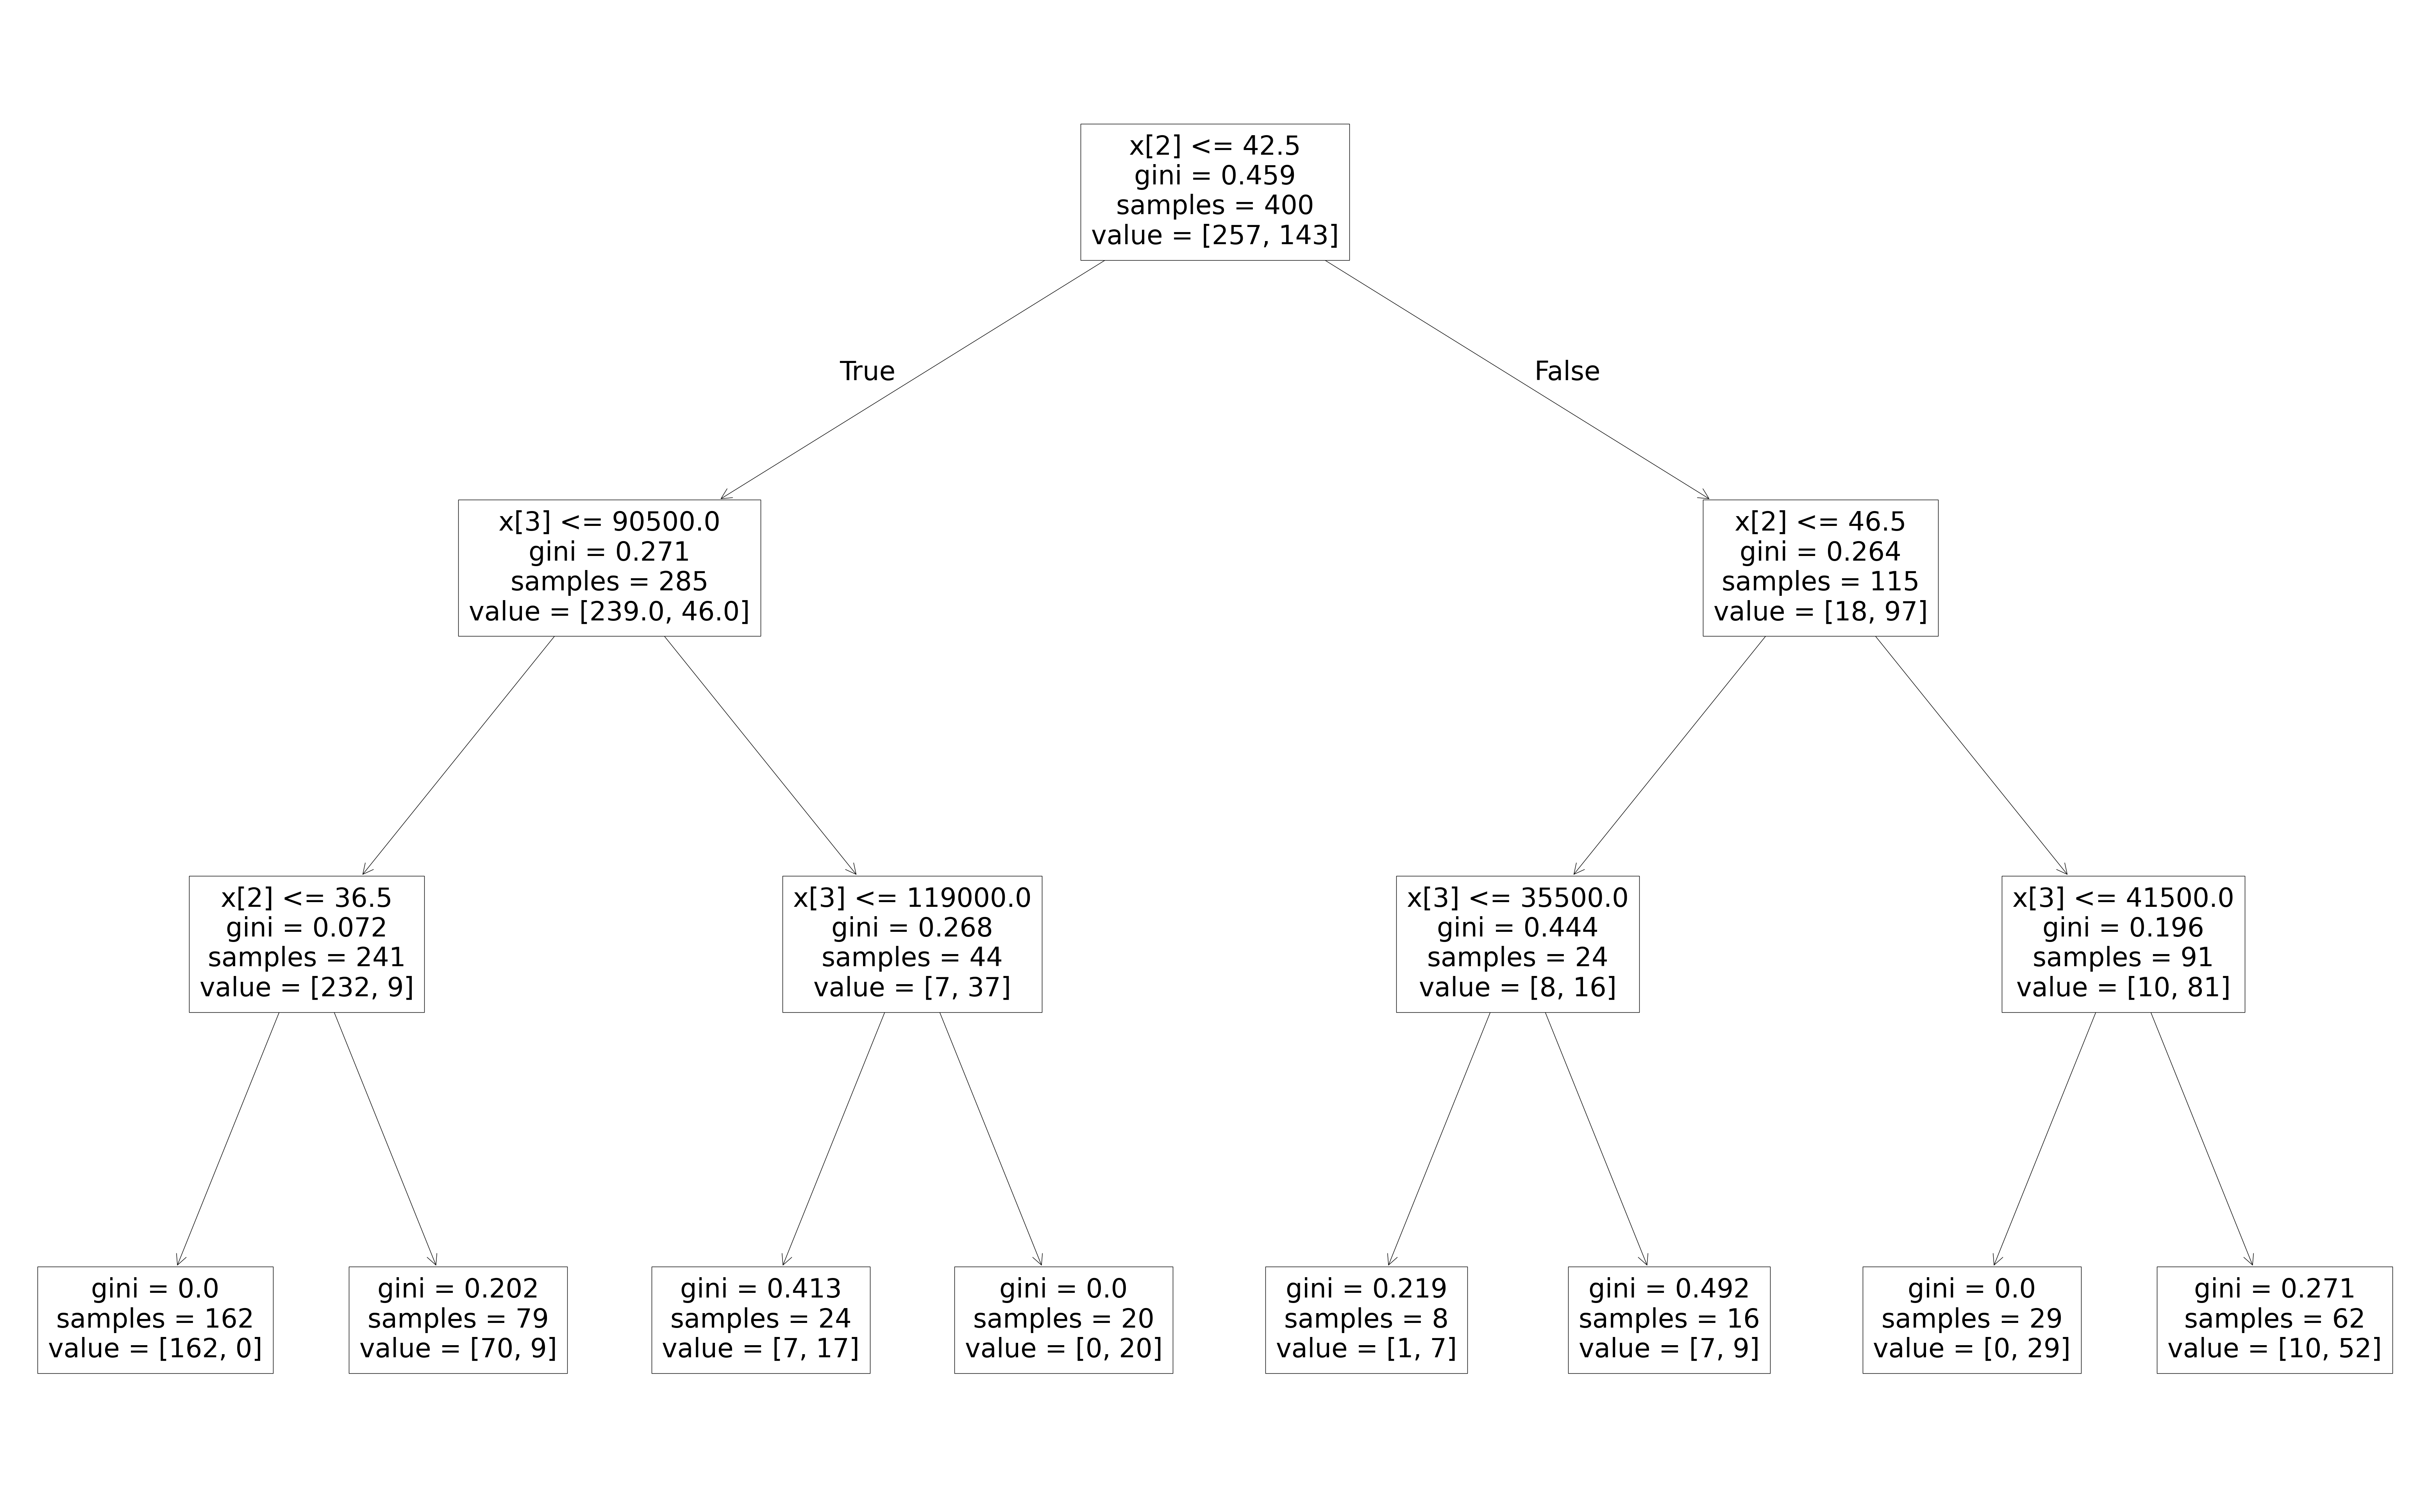

In [86]:
X = data_1.drop(columns=['Purchased'], axis=1)   
y = data_1['Purchased']                           

# Train with max_depth=3 to limit tree complexity (reduces overfitting)
clf1 = DecisionTreeClassifier(max_depth=3)
clf1.fit(X, y)

# Visualize the depth-limited tree — much more compact and readable
rcParams['figure.figsize'] = 80, 50
plot_tree(clf1)
plt.show()

### Training with Entropy Criterion (Full Tree)

Here we train a **fully grown tree** using the **Entropy** criterion (Information Gain).
Comparing the tree structure to the Gini tree illustrates how different criteria can produce different splits — though accuracy is often similar.

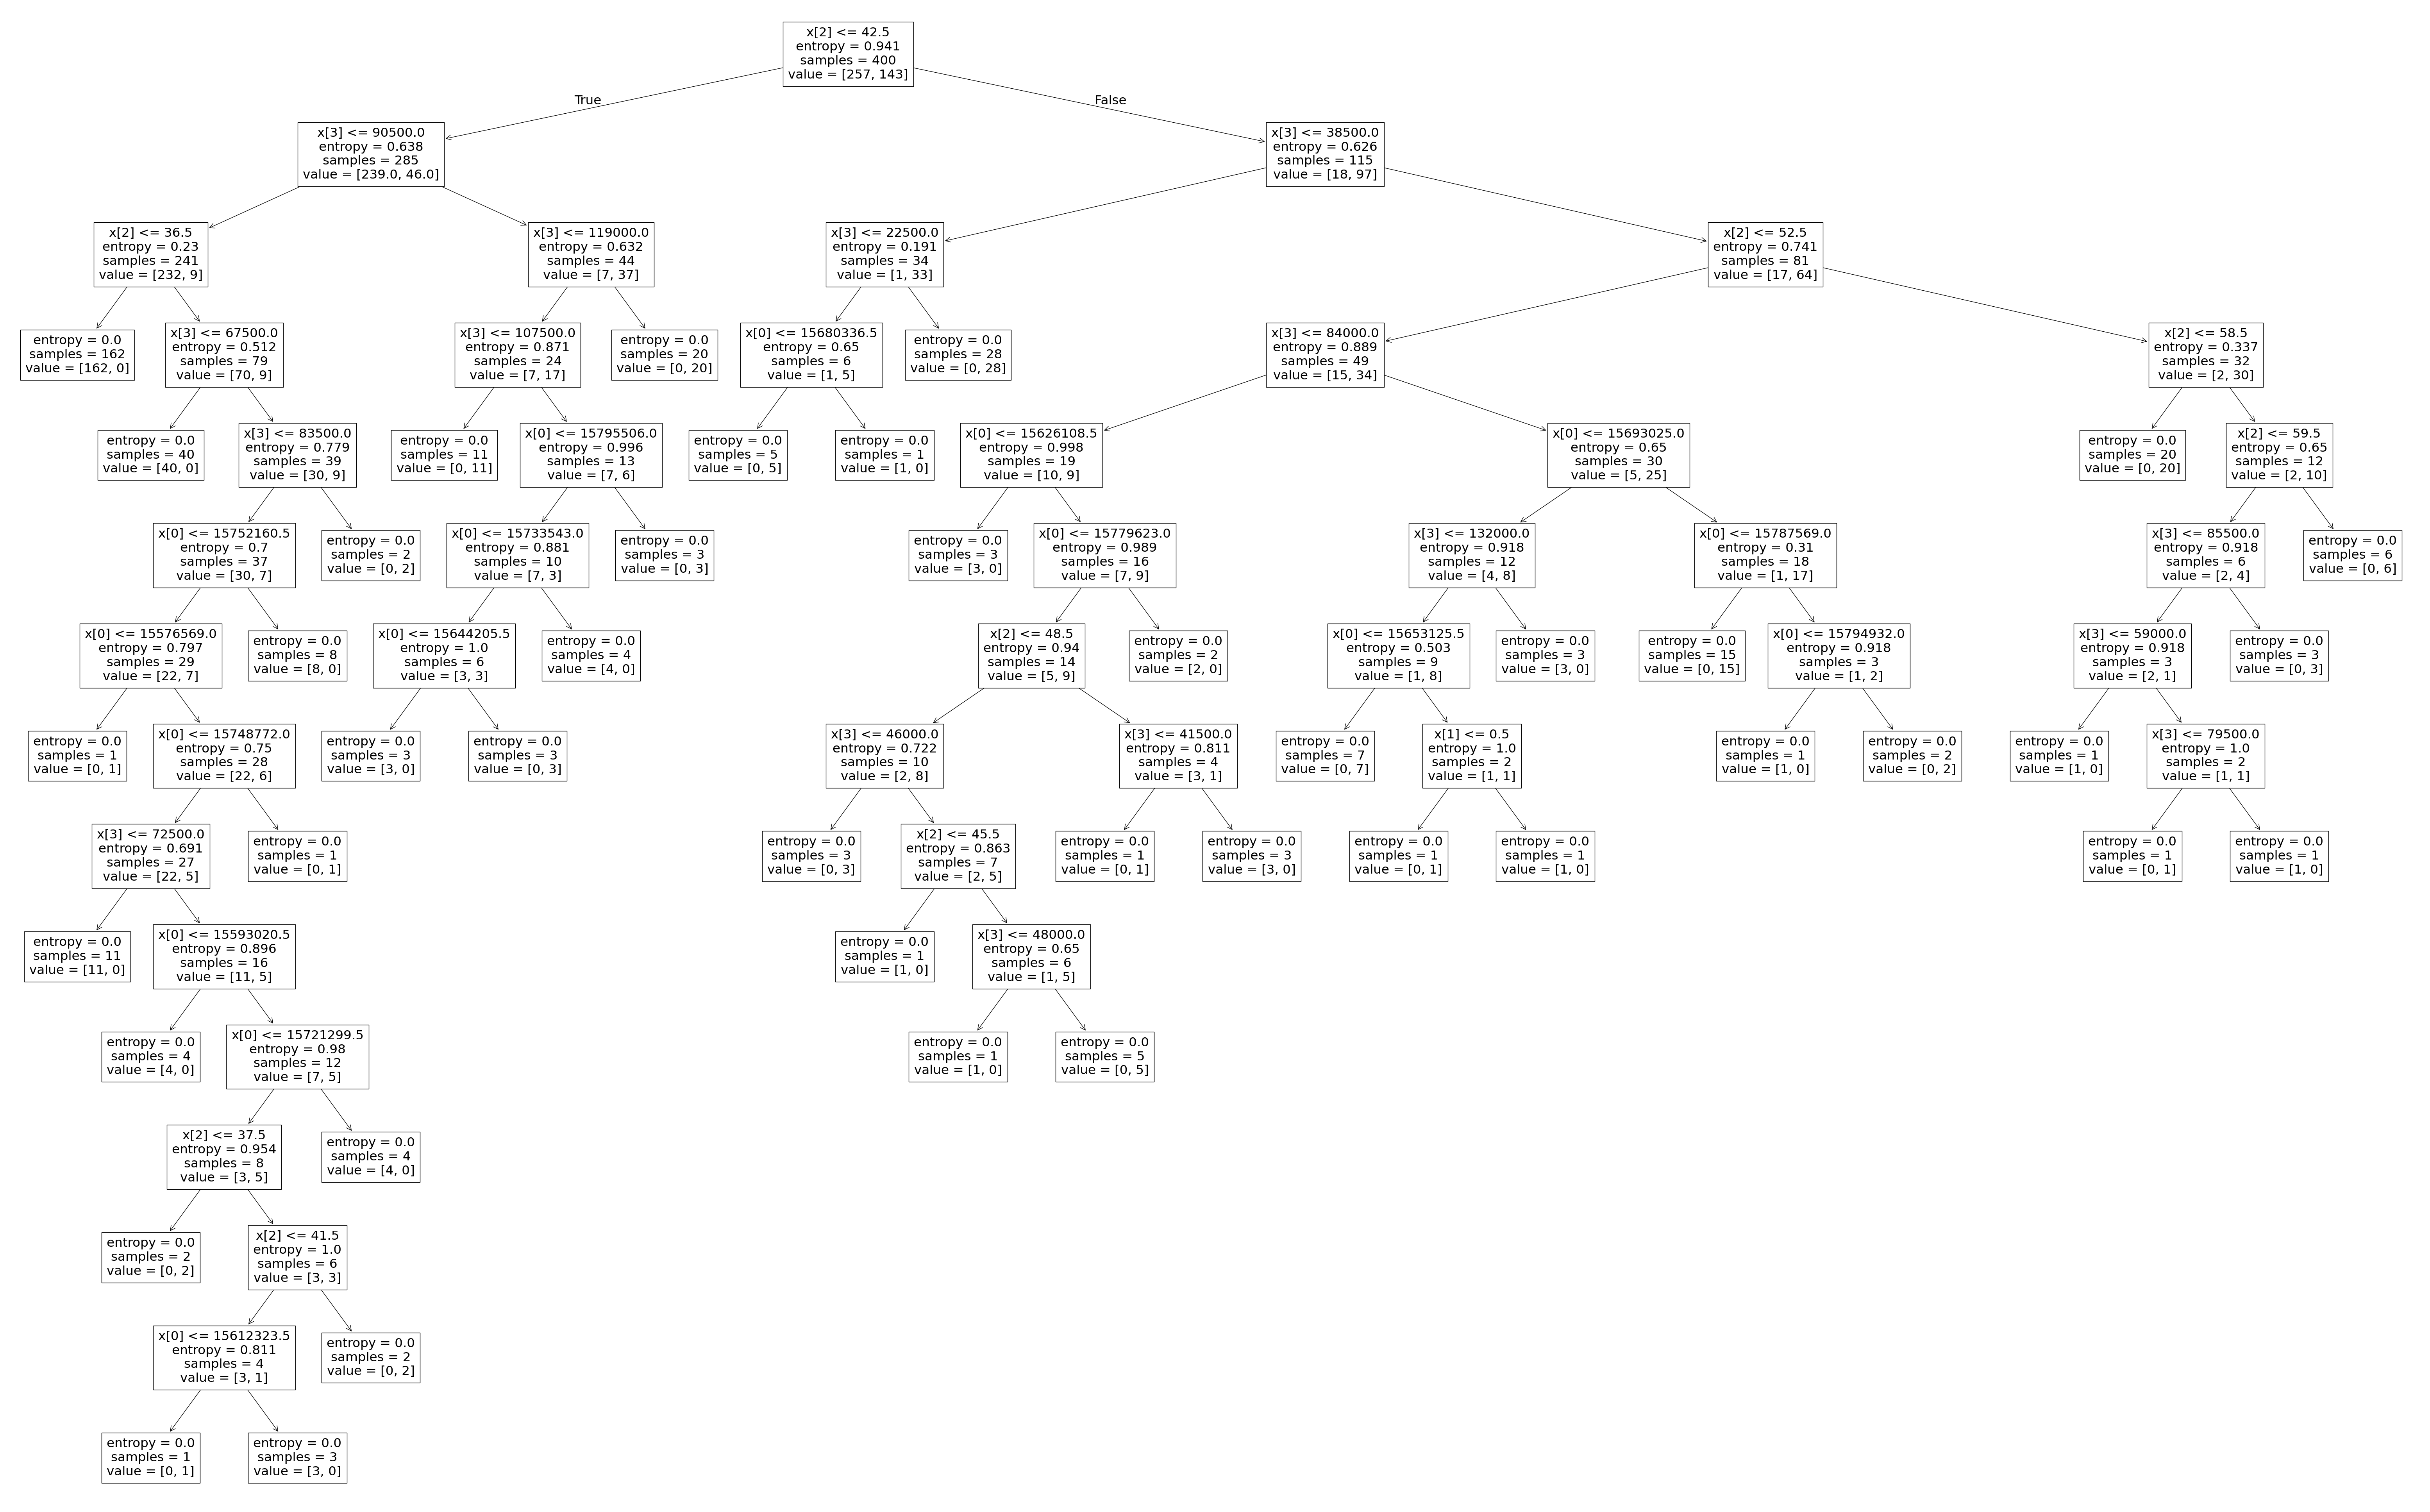

In [88]:
# Train a fully grown Decision Tree using Entropy criterion
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)

# Visualize — this tree will be larger/deeper than the max_depth=3 version
rcParams['figure.figsize'] = 80, 50
plot_tree(clf)
plt.show()

## Summary 

| Experiment | Criterion | `max_depth` | Notes |
|------------|-----------|-------------|-------|
| Iris | Gini | None | Fully grown — may overfit |
| Social Ads | Gini | 3 | Constrained — better generalization |
| Social Ads | Entropy | None | Fully grown with entropy splits |

   ```

 